## Logistic Regression Implementation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification

In [4]:
## create the dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=15)

In [5]:
from sklearn.decomposition import PCA

In [6]:
##Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
pc = PCA(n_components= 2, )
pc.fit_transform(X_train)

array([[ 0.80711051,  1.29886894],
       [-3.35583169, -1.58913072],
       [ 1.30018496, -1.01820075],
       ...,
       [ 2.31163158,  1.09861288],
       [-0.79655849,  1.26794451],
       [-1.72160472, -1.77846208]], shape=(800, 2))

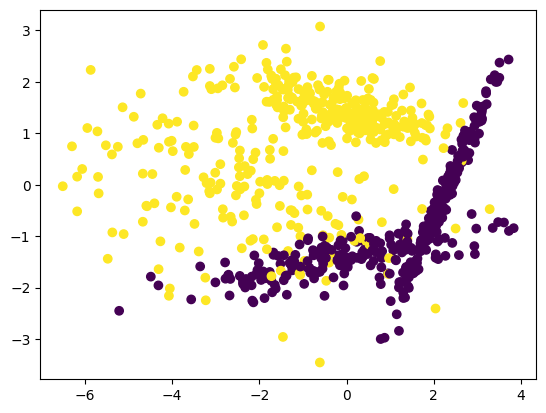

In [8]:
plt.scatter(pc.fit_transform(X_train)[:,0],pc.fit_transform(X_train)[:,1],c = y_train)
##This is how data looks like for the classification problem
##There is some anomaly but can see little distinction between two class

## Basic Modelling

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as m

In [10]:
##Basic modelling technique used
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
##Evaluations

y_pred = lr_model.predict(X_test)

print(m.classification_report(y_test,y_pred))

print("Accuracy Score:",m.accuracy_score(y_test,y_pred))
print("Precision Score:",round(m.precision_score(y_test,y_pred),2))
print("Recall Score:",round(m.recall_score(y_test,y_pred),2))
print("F1 Score:",round(m.f1_score(y_test,y_pred),2))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       101
           1       0.95      0.91      0.93        99

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200

Accuracy Score: 0.93
Precision Score: 0.95
Recall Score: 0.91
F1 Score: 0.93


In [12]:
lr_model.predict_proba(X_train) 
##First Probability of data point being 0 & Second for 1
##Which-everis higher that is used to classify the y

array([[0.0976892 , 0.9023108 ],
       [0.17853949, 0.82146051],
       [0.97262543, 0.02737457],
       ...,
       [0.4997704 , 0.5002296 ],
       [0.00826605, 0.99173395],
       [0.63953989, 0.36046011]], shape=(800, 2))

In [13]:
lr_model.predict(X_train)

array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,

## Hyperparameter Tuning

In [14]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Grid SearchCV

In [15]:
model_lr=LogisticRegression()
param_grid = {'penalty': ['l1', 'l2', 'elasticnet'],
               'C':[100,10,1.0,0.1,0.01],
               'solver':['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

In [16]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold() ## In case of uneven class it ensure folds are equal value for all the classes in each partition

In [17]:
## GridSearchCV
from sklearn.model_selection import GridSearchCV

grid=GridSearchCV(estimator=model_lr,param_grid=param_grid,scoring='accuracy',cv=cv,n_jobs=-1)

In [18]:
grid.fit(X_train,y_train)

c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
200 fits failed out of a total of 375.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\rachi\OneDriv

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [20]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [21]:
grid.best_score_

np.float64(0.9262499999999999)

In [22]:
##Evaluations

y_pred1 = grid.predict(X_test)

print(m.classification_report(y_test,y_pred1))

print("Accuracy Score:",m.accuracy_score(y_test,y_pred1))
print("Precision Score:",round(m.precision_score(y_test,y_pred1),2))
print("Recall Score:",round(m.recall_score(y_test,y_pred1),2))
print("F1 Score:",round(m.f1_score(y_test,y_pred1),2))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       101
           1       0.97      0.91      0.94        99

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

Accuracy Score: 0.94
Precision Score: 0.97
Recall Score: 0.91
F1 Score: 0.94


## Randomized SearchCV

In [23]:
from sklearn.model_selection import RandomizedSearchCV

In [24]:
model=LogisticRegression()
randomcv=RandomizedSearchCV(estimator=model_lr,param_distributions=param_grid,cv=5,scoring='accuracy')

In [25]:
randomcv.fit(X_train,y_train) ##earlier model took 354 ms where it took 194 ms

c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\rachi\OneDrive\D

,estimator,LogisticRegression()
,param_distributions,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [26]:
randomcv.best_score_

np.float64(0.91875)

In [27]:
randomcv.best_params_

{'solver': 'saga', 'penalty': 'l1', 'C': 0.01}

In [28]:
##Evaluations

y_pred2 = randomcv.predict(X_test)

print(m.classification_report(y_test,y_pred2))

print("Accuracy Score:",m.accuracy_score(y_test,y_pred2))
print("Precision Score:",round(m.precision_score(y_test,y_pred2),2))
print("Recall Score:",round(m.recall_score(y_test,y_pred2),2))
print("F1 Score:",round(m.f1_score(y_test,y_pred2),2)) ##It randomised get the grid, however it is faster


              precision    recall  f1-score   support

           0       0.91      0.97      0.94       101
           1       0.97      0.90      0.93        99

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200

Accuracy Score: 0.935
Precision Score: 0.97
Recall Score: 0.9
F1 Score: 0.93


## ROC-AUC Curve

In [94]:
y_proba = grid.predict_proba(X_test)[:,1]
fpr, tpr, probab = m.roc_curve(y_test, y_proba)
auc_value = m.roc_auc_score(y_test, y_proba)

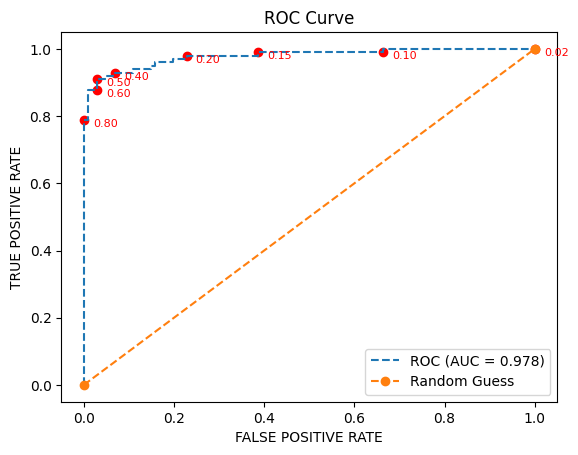

In [100]:
plt.clf()
plt.plot(fpr, tpr, "--", label=f"ROC (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], '--o', label="Random Guess")


important_thresholds = [0.1,0.2,0.4, 0.6,0.5, 0.8,.15,.02]
for thr in important_thresholds:
    #returns the index of the smallest difference — i.e., where the threshold value is closest to your target.
    idx = np.argmin(np.abs(probab - thr))
    plt.scatter(fpr[idx], tpr[idx], color='red')
    ##+0.2 to show the text
    plt.text(fpr[idx]+0.02, tpr[idx]-0.02, f"{thr:.2f}", color='red', fontsize=8)


plt.xlabel("FALSE POSITIVE RATE")
plt.ylabel("TRUE POSITIVE RATE")
plt.title("ROC Curve")
plt.legend(loc="lower right")
# plt.show()

## Conclusion

Why default Threshold is working as we can se 0.5 perfect blend of FPR & TPR